In [7]:
import numpy as np
import pandas as pd

# 1. Configuración inicial y reproducibilidad
np.random.seed(42)

# Rango de fechas continuo (2 años)
fechas = pd.date_range(start="2024-01-01", end="2025-12-31", freq="D")
rutas = ["Ruta_A-B", "Ruta_A-C", "Ruta_A-D", "Ruta_B-C", "Ruta_B-D", "Ruta_C-D"]
car_types = ["bus", "minibus", "van"]
payment_methods = ["cash", "card", "mobile_payment"]

data_list = []

for ruta in rutas:
    demanda_base_ruta = np.random.randint(80, 150)

    for idx, fecha in enumerate(fechas):
        # Cada día, la ruta opera con una combinación de flota y tendencias de pago
        for car in car_types:
            for payment in payment_methods:

                # --- VARIABLE 1: EFECTO DEL TIPO DE VEHÍCULO (CAR TYPE) ---
                # Los buses grandes absorben más demanda; las vans son para flujos menores
                if car == "bus":
                    factor_car = 2.0
                elif car == "minibus":
                    factor_car = 1.2
                else: # van
                    factor_car = 0.5

                # --- VARIABLE 2: EFECTO DEL MÉTODO DE PAGO ---
                # Supongamos que el pago móvil es popular a fin de mes (quincena) y efectivo a mitad
                if payment == "mobile_payment" and (fecha.day in [15, 30, 31]):
                    factor_payment = 15
                elif payment == "card" and fecha.weekday() in [4, 5]: # Tarjeta en fin de semana
                    factor_payment = 10
                else:
                    factor_payment = 0

                # --- COMPONENTE 3: TENDENCIA TEMPORAL ---
                tendencia = idx * 0.02 # Crecimiento orgánico de la empresa

                # --- COMPONENTE 4: ESTACIONALIDAD SEMANAL ---
                if fecha.weekday() in [4, 5]:  # Viernes y Sábado
                    estacionalidad_semanal = 25
                elif fecha.weekday() == 6:     # Domingo baja
                    estacionalidad_semanal = -154
                else:
                    estacionalidad_semanal = 0

                # --- COMPONENTE 5: ESTACIONALIDAD ANUAL (VACACIONES) ---
                if fecha.month in [6, 12]:
                    estacionalidad_anual = 35
                else:
                    estacionalidad_anual = 0

                # --- COMPONENTE 6: RUIDO ALEATORIO (Complejidad para la RNN) ---
                ruido = np.random.normal(loc=0, scale=8)

                # --- CÁLCULO DE LA DEMANDA ESPECÍFICA ---
                # Combinamos la base de la ruta multiplicada por el tipo de auto, más factores temporales y de pago
                demanda_segmentada = (demanda_base_ruta * factor_car) + tendencia + estacionalidad_semanal + estacionalidad_anual + factor_payment + ruido
                demanda_segmentada = max(2, int(demanda_segmentada)) # Asegurar valores positivos mínimos

                data_list.append({
                    'fecha': fecha,
                    'ruta': ruta,
                    'car_type': car,
                    'payment_method': payment,
                    'demanda_pasajeros': demanda_segmentada
                })

# Crear y exportar el DataFrame
df_complejo = pd.DataFrame(data_list)
df_complejo.to_csv("demanda_transporte_complejo.csv", index=False)



print(f"Dataset generado con {df_complejo.shape[0]} registros.")
print(df_complejo.head(10))

Dataset generado con 39474 registros.
       fecha      ruta car_type  payment_method  demanda_pasajeros
0 2024-01-01  Ruta_A-B      bus            cash                253
1 2024-01-01  Ruta_A-B      bus            card                264
2 2024-01-01  Ruta_A-B      bus  mobile_payment                264
3 2024-01-01  Ruta_A-B  minibus            cash                165
4 2024-01-01  Ruta_A-B  minibus            card                152
5 2024-01-01  Ruta_A-B  minibus  mobile_payment                152
6 2024-01-01  Ruta_A-B      van            cash                 60
7 2024-01-01  Ruta_A-B      van            card                 58
8 2024-01-01  Ruta_A-B      van  mobile_payment                 44
9 2024-01-02  Ruta_A-B      bus            cash                269


## Procesamiento de Datos


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Cargar el dataset generado en el paso anterior
df = pd.read_csv("demanda_transporte_complejo.csv")
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Extraer características numéricas de la fecha (Crucial para Regresión)
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.weekday
df['es_fin_de_semana'] = df['dia_semana'].isin([4, 5]).astype(int) # Viernes y Sábados masivos
df['dia_mes'] = df['fecha'].dt.day

# 3. Aplicar One-Hot Encoding a las variables categóricas (Ruta, Car_Type, Payment_Method)
# Esto convierte las palabras en columnas de 0 y 1
df_encoded = pd.get_dummies(df, columns=['ruta', 'car_type', 'payment_method'], drop_first=True)


X = df_encoded.drop(columns=['fecha', 'demanda_pasajeros'])
y = df_encoded['demanda_pasajeros']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Características preparadas para el modelo: {list(X.columns)}")

Características preparadas para el modelo: ['mes', 'dia_semana', 'es_fin_de_semana', 'dia_mes', 'ruta_Ruta_A-C', 'ruta_Ruta_A-D', 'ruta_Ruta_B-C', 'ruta_Ruta_B-D', 'ruta_Ruta_C-D', 'car_type_minibus', 'car_type_van', 'payment_method_cash', 'payment_method_mobile_payment']


In [20]:
# 1. Inicializar y entrenar el modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# 2. Realizar predicciones sobre el set de prueba
y_pred = modelo_lineal.predict(X_test)

# 3. Calcular Métricas de Evaluación (Exigidas en la Rúbrica)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n--- METRICAS DE EVALUACIÓN (BASELINE LINEAL) ---")
print(f"MAE (Error Absoluto Medio): {mae:.2f} pasajeros")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} pasajeros")


--- METRICAS DE EVALUACIÓN (BASELINE LINEAL) ---
MAE (Error Absoluto Medio): 24.06 pasajeros
RMSE (Raíz del Error Cuadrático Medio): 29.94 pasajeros


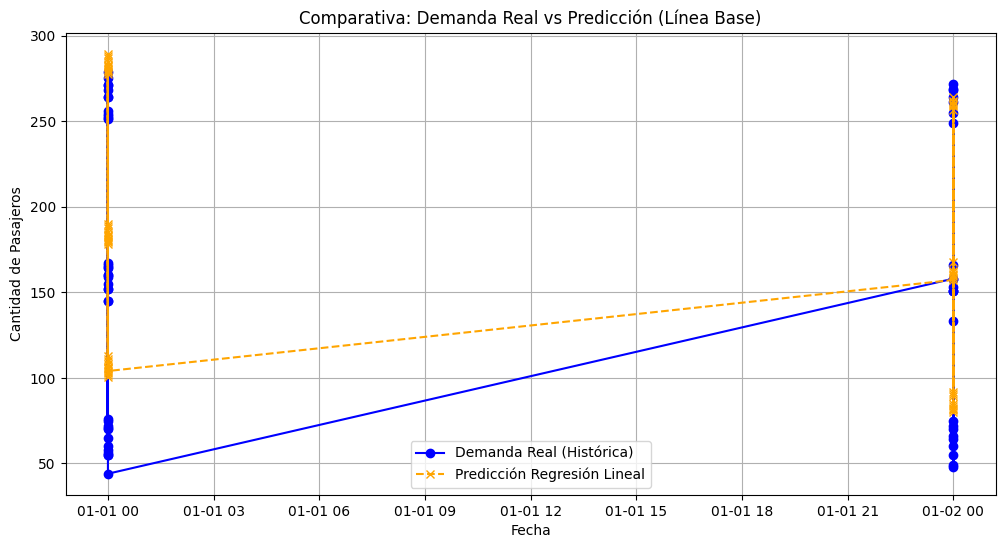

In [21]:
# Crear un subset de prueba ordenado cronológicamente para una visualización clara
df_visualizacion = df_encoded[(df_encoded['ruta_Ruta_A-C'] == 0) & (df_encoded['ruta_Ruta_B-C'] == 0)].sort_values('fecha').head(60)

X_vis = df_visualizacion.drop(columns=['fecha', 'demanda_pasajeros'])
y_vis = df_visualizacion['demanda_pasajeros']
y_pred_vis = modelo_lineal.predict(X_vis)


plt.figure(figsize=(12, 6))
plt.plot(df_visualizacion['fecha'], y_vis, label='Demanda Real (Histórica)', color='blue', marker='o')
plt.plot(df_visualizacion['fecha'], y_pred_vis, label='Predicción Regresión Lineal', color='orange', linestyle='--', marker='x')
plt.title('Comparativa: Demanda Real vs Predicción (Línea Base)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.legend()
plt.grid(True)
plt.show()